# Data Cleaning & Intigration

In [9]:
import pandas as pd

#file path 
file1_path = "../Data/Bird_Monitoring_Data_FOREST.xlsx"
file2_path = "../Data/Bird_Monitoring_Data_GRASSLAND.xlsx"

# read the excel file 
excel_data1 = pd.ExcelFile(file1_path)
excel_data2 = pd.ExcelFile(file2_path)

# get all sheet names
sheet_names1 = excel_data1.sheet_names
sheet_names2 = excel_data2.sheet_names

# read data from all sheets into a dictionary
sheets_dict1 = {sheet: excel_data1.parse(sheet) for sheet in sheet_names1}
sheets_dict2 = {sheet: excel_data2.parse(sheet) for sheet in sheet_names2}

In [10]:
# multiple sheets to a single dataframe
combined_df1 = pd.concat(
    [df.assign(Sheet=sheet_name) for sheet_name, df in sheets_dict1.items()],
    ignore_index=True
)

combined_df2 = pd.concat(
    [df.assign(Sheet=sheet_name) for sheet_name, df in sheets_dict2.items()],
    ignore_index=True
)

C:\Users\HP\AppData\Local\Temp\ipykernel_540\899211193.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df2 = pd.concat(


In [11]:
#drop sheet column 

combined_df1 = combined_df1.drop(columns=['Sheet'])
combined_df2 = combined_df2.drop(columns=['Sheet'])

In [12]:
#cleaning combined_df1 first:

combined_df1.isnull().sum()

Admin_Unit_Code                   0
Sub_Unit_Code                  7824
Site_Name                         0
Plot_Name                         0
Location_Type                     0
Year                              0
Date                              0
Start_Time                        0
End_Time                          0
Observer                          0
Visit                             0
Interval_Length                   0
ID_Method                         1
Distance                         92
Flyover_Observed                  0
Sex                            5183
Common_Name                       0
Scientific_Name                   0
AcceptedTSN                       9
NPSTaxonCode                      0
AOU_Code                          0
PIF_Watchlist_Status              0
Regional_Stewardship_Status       0
Temperature                       0
Humidity                          0
Sky                               0
Wind                              0
Disturbance                 

In [13]:
# handling 'Sex' column
combined_df1['Sex'] = combined_df1['Sex'].fillna('Unknown')
# handling 'Sub_Unit_Code' column
combined_df1['Sub_Unit_Code'] = combined_df1['Sub_Unit_Code'].fillna('NA')
# handling 'Distance' column
combined_df1['Distance'] = combined_df1['Distance'].fillna('Not recorded')

In [14]:
combined_df1 = combined_df1.dropna()
combined_df1.isnull().sum()

Admin_Unit_Code                0
Sub_Unit_Code                  0
Site_Name                      0
Plot_Name                      0
Location_Type                  0
Year                           0
Date                           0
Start_Time                     0
End_Time                       0
Observer                       0
Visit                          0
Interval_Length                0
ID_Method                      0
Distance                       0
Flyover_Observed               0
Sex                            0
Common_Name                    0
Scientific_Name                0
AcceptedTSN                    0
NPSTaxonCode                   0
AOU_Code                       0
PIF_Watchlist_Status           0
Regional_Stewardship_Status    0
Temperature                    0
Humidity                       0
Sky                            0
Wind                           0
Disturbance                    0
Initial_Three_Min_Cnt          0
dtype: int64

In [15]:
#cleaning combined_df2 :

combined_df2.isnull().sum()

Admin_Unit_Code                   0
Sub_Unit_Code                  8531
Plot_Name                         0
Location_Type                     0
Year                              0
Date                              0
Start_Time                        0
End_Time                          0
Observer                          0
Visit                             0
Interval_Length                   0
ID_Method                         1
Distance                       1394
Flyover_Observed                  0
Sex                               0
Common_Name                       0
Scientific_Name                   0
AcceptedTSN                      24
TaxonCode                         2
AOU_Code                          0
PIF_Watchlist_Status              0
Regional_Stewardship_Status       0
Temperature                       0
Humidity                          0
Sky                               0
Wind                              0
Disturbance                       0
Previously_Obs              

In [35]:

# handling 'Sub_Unit_Code' column
combined_df2['Sub_Unit_Code'] = combined_df2['Sub_Unit_Code'].fillna('NA')
# handling 'Distance' column
combined_df2['Distance'] = combined_df2['Distance'].fillna('Not recorded')

In [36]:
combined_df2 = combined_df2.dropna()
combined_df2.isnull().sum()

Admin_Unit_Code                0
Sub_Unit_Code                  0
Plot_Name                      0
Location_Type                  0
Year                           0
Date                           0
Start_Time                     0
End_Time                       0
Observer                       0
Visit                          0
Interval_Length                0
ID_Method                      0
Distance                       0
Flyover_Observed               0
Sex                            0
Common_Name                    0
Scientific_Name                0
AcceptedTSN                    0
Taxon_Code                     0
AOU_Code                       0
PIF_Watchlist_Status           0
Regional_Stewardship_Status    0
Temperature                    0
Humidity                       0
Sky                            0
Wind                           0
Disturbance                    0
Previously_Obs                 0
Initial_Three_Min_Cnt          0
Habitat                        0
dtype: int

In [37]:
# droping duplicate rows 
combined_df1.drop_duplicates()
combined_df2.drop_duplicates()

,Admin_Unit_Code,Sub_Unit_Code,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,...,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Previously_Obs,Initial_Three_Min_Cnt,Habitat
0,ANTI,NA,ANTI-0054,Grassland,2018,2018-05-22,1900-01-01 05:34:50,1900-01-01 05:44:50,Elizabeth Oswald,1,...,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True,Grassland
1,ANTI,NA,ANTI-0054,Grassland,2018,2018-05-22,1900-01-01 05:34:50,1900-01-01 05:44:50,Elizabeth Oswald,1,...,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,False,Grassland
2,ANTI,NA,ANTI-0054,Grassland,2018,2018-05-22,1900-01-01 05:34:50,1900-01-01 05:44:50,Elizabeth Oswald,1,...,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True,Grassland
3,ANTI,NA,ANTI-0054,Grassland,2018,2018-05-22,1900-01-01 05:34:50,1900-01-01 05:44:50,Elizabeth Oswald,1,...,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True,Grassland
4,ANTI,NA,ANTI-0054,Grassland,2018,2018-05-22,1900-01-01 05:34:50,1900-01-01 05:44:50,Elizabeth Oswald,1,...,False,True,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True,Grassland
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8514,MONO,NA,MONO-0089,Grassland,2018,2018-05-10,1900-01-01 06:34:50,1900-01-01 06:45:50,Brian Swimelar,1,...,False,False,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,True,Grassland
8515,MONO,NA,MONO-0089,Grassland,2018,2018-05-10,1900-01-01 06:34:50,1900-01-01 06:45:50,Brian Swimelar,1,...,False,False,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,False,Grassland
8516,MONO,NA,MONO-0089,Grassland,2018,2018-05-10,1900-01-01 06:34:50,1900-01-01 06:45:50,Brian Swimelar,1,...,False,True,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,True,Grassland
8517,MONO,NA,MONO-0089,Grassland,2018,2018-05-10,1900-01-01 06:34:50,1900-01-01 06:45:50,Brian Swimelar,1,...,False,False,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,True,Grassland


In [38]:
# Unify the Taxon Code column name
if 'NPSTaxonCode' in combined_df1.columns:
    combined_df1.rename(columns={'NPSTaxonCode': 'Taxon_Code'}, inplace=True)

if 'TaxonCode' in combined_df2.columns:
    combined_df2.rename(columns={'TaxonCode': 'Taxon_Code'}, inplace=True)

In [39]:
# Adding a Habitat identifier
combined_df1['Habitat'] = 'Forest'
combined_df2['Habitat'] = 'Grassland'

In [40]:
# Concatenating dataframes into the final Master dataframe
master_df = pd.concat([combined_df1, combined_df2], ignore_index=True, sort=False)

# Final check for any remaining nulls across the whole dataset
print(master_df.isnull().sum())

Admin_Unit_Code                   0
Sub_Unit_Code                     0
Site_Name                      8504
Plot_Name                         0
Location_Type                     0
Year                              0
Date                              0
Start_Time                        0
End_Time                          0
Observer                          0
Visit                             0
Interval_Length                   0
ID_Method                         0
Distance                          0
Flyover_Observed                  0
Sex                               0
Common_Name                       0
Scientific_Name                   0
AcceptedTSN                       0
Taxon_Code                        0
AOU_Code                          0
PIF_Watchlist_Status              0
Regional_Stewardship_Status       0
Temperature                       0
Humidity                          0
Sky                               0
Wind                              0
Disturbance                 

In [41]:
# handling 'Sitename' column
master_df['Site_Name'] = master_df['Site_Name'].fillna('Unknown')

In [42]:
# handling 'Previously_obs' column
master_df['Previously_Obs'] = master_df['Previously_Obs'].fillna('Undetermined')

# Exploratory Data Analysis

### Top 10 Species

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

#Analysis of top 10 overall species..
top_10_overall = master_df['Common_Name'].value_counts().head(10)

#Analysis of top 10 Forest spcies..
top_10_forest = combined_df1['Common_Name'].value_counts().head(10)

#Analysis of top 10 Grassland spcies..
top_10_grassland = combined_df2['Common_Name'].value_counts().head(10)


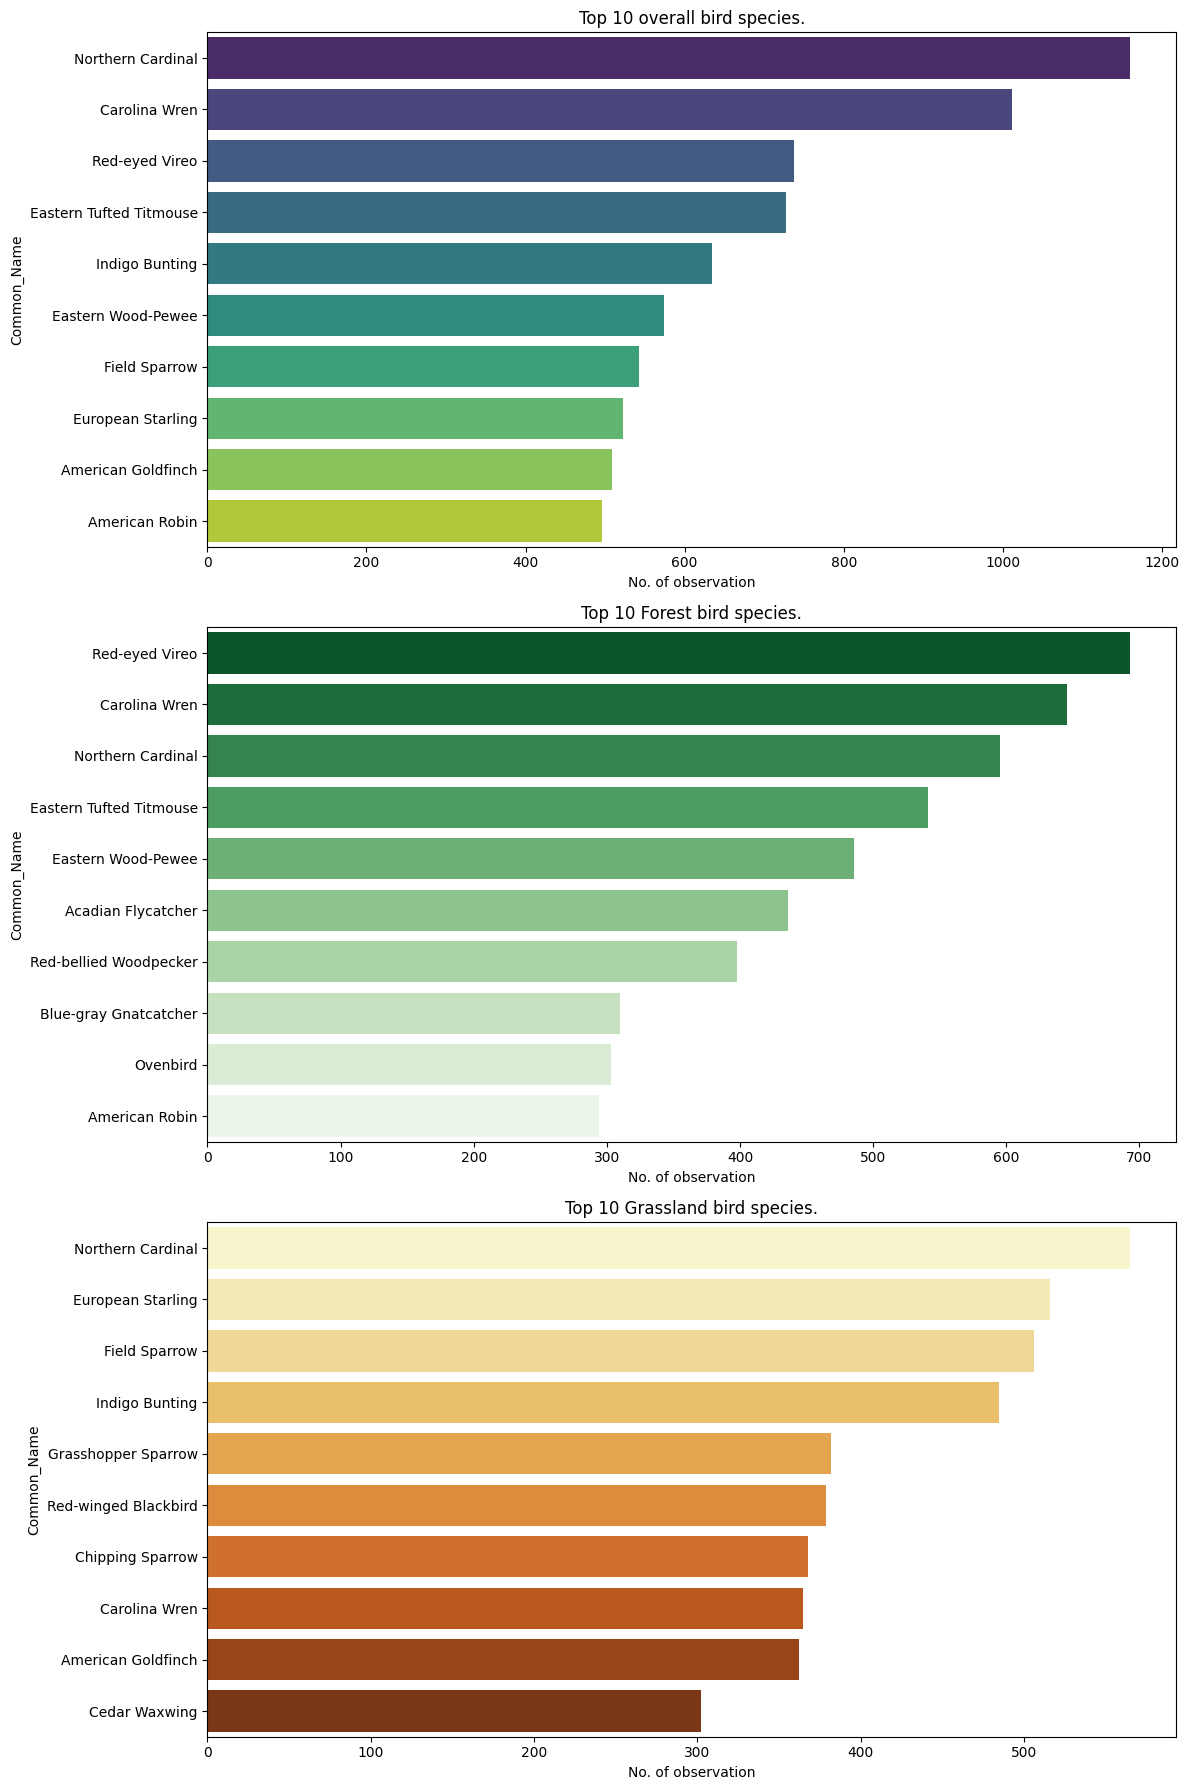

Top 10 Overall:
 Common_Name
Northern Cardinal          1160
Carolina Wren              1011
Red-eyed Vireo              738
Eastern Tufted Titmouse     728
Indigo Bunting              635
Eastern Wood-Pewee          574
Field Sparrow               542
European Starling           522
American Goldfinch          509
American Robin              496
Name: count, dtype: int64

Top 10 Forest:
 Common_Name
Red-eyed Vireo             693
Carolina Wren              646
Northern Cardinal          595
Eastern Tufted Titmouse    541
Eastern Wood-Pewee         486
Acadian Flycatcher         436
Red-bellied Woodpecker     398
Blue-gray Gnatcatcher      310
Ovenbird                   303
American Robin             294
Name: count, dtype: int64

Top 10 Grassland:
 Common_Name
Northern Cardinal       565
European Starling       516
Field Sparrow           506
Indigo Bunting          485
Grasshopper Sparrow     382
Red-winged Blackbird    379
Chipping Sparrow        368
Carolina Wren           365
Amer

In [25]:
# visualization 

plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.barplot(x = top_10_overall.values , y = top_10_overall.index, hue=top_10_overall.index , palette='viridis', legend=False)
plt.title('Top 10 overall bird species.')
plt.xlabel('No. of observation')

plt.subplot(3,1,2)
sns.barplot(x = top_10_forest.values , y = top_10_forest.index , hue=top_10_forest.index, palette='Greens_r', legend=False)
plt.title('Top 10 Forest bird species.')
plt.xlabel('No. of observation')

plt.subplot(3,1,3)
sns.barplot(x = top_10_grassland.values , y = top_10_grassland.index ,hue=top_10_grassland.index, palette='YlOrBr' , legend=False)
plt.title('Top 10 Grassland bird species.')
plt.xlabel('No. of observation')

plt.tight_layout()
plt.savefig('top_10_species.png')
plt.show()
plt.close()

print("Top 10 Overall:\n", top_10_overall)
print("\nTop 10 Forest:\n", top_10_forest)
print("\nTop 10 Grassland:\n", top_10_grassland)

### Environmental Correlation

In [26]:
# cleaning environmental columns 

env_cols  =  ['Temperature', 'Humidity' , 'Sky' , 'Wind']
clean_env_df = master_df.dropna(subset=env_cols).copy()

In [27]:
# Temperature Correlation
clean_env_df['Temp_bin'] = pd.cut(clean_env_df['Temperature'] , bins=range(0,110,10))
temp_counts = clean_env_df['Temp_bin'].value_counts().sort_index()

# Wind Correlation
# Grouping by wind
wind_counts = clean_env_df['Wind'].value_counts()

# Sky condition correlation
sky_counts = clean_env_df['Sky'].value_counts() 

In [28]:
# Visualization

plt.figure(figsize=(15,12))

# Subplot 1:Temperature
plt.subplot(2,2,1)
sns.barplot(x = temp_counts.index.astype(str) , y=temp_counts.values,hue=temp_counts.values, palette='coolwarm' , legend=False )
plt.title('Observation Frequency by Temperature Range')
plt.xlabel('Temperature Range (F)')
plt.ylabel('Observation Count')
plt.xticks(rotation=45)

#Subplot 2: Wind
plt.subplot(2,2,2)
sns.barplot(x = wind_counts.values , y = wind_counts.index , hue = wind_counts.index , palette='Blues_d', legend=False)
plt.title('Observations by Wind Condition')
plt.xlabel('Observation Count')

#Subplot 3: Sky Condition
plt.subplot(2, 2, 3)
sns.barplot(x=sky_counts.values, y=sky_counts.index, hue=sky_counts.index, palette='magma' , legend=False)
plt.title('Observations by Sky Condition')
plt.xlabel('Observation Count')

# Subplot 4: Humidity vs Temperature Scatter 
plt.subplot(2, 2, 4)
sns.scatterplot(data=clean_env_df.sample(min(1000, len(clean_env_df))), x='Temperature', y='Humidity', hue='Habitat', alpha=0.6)
plt.title('Temperature vs Humidity Correlation')

plt.tight_layout()
plt.savefig('environmental_correlation.png')
plt.close()

# Descriptive stats for env factors
env_stats = clean_env_df[env_cols].describe()
print(env_stats)

        Temperature      Humidity
count  17040.000000  17040.000000
mean      22.572400     73.694842
std        4.265353     12.331118
min       11.000000      7.300000
25%       19.700001     67.500000
50%       22.299999     75.800003
75%       25.200001     83.000000
max       37.299999     98.800003


### Site Analysis

In [43]:
import numpy as np

master_df['Date'] = pd.to_datetime(master_df['Date'], errors='coerce')
master_df['Month'] = master_df['Date'].dt.month
master_df['Year_from_Date'] = master_df['Date'].dt.year

In [44]:

def extract_hour(t):
    if pd.isnull(t):
        return np.nan
    if isinstance(t, str):
        try:
            return int(t.split(':')[0])
        except:
            return np.nan
    try:
        return t.hour
    except:
        return np.nan

In [31]:
master_df['Start_Hour'] = master_df['Start_Time'].apply(extract_hour)

In [32]:
yearly_trends = master_df.groupby(['Year', 'Habitat']).size().unstack().fillna(0)
monthly_trends = master_df.groupby(['Month', 'Habitat']).size().unstack().fillna(0)
hourly_trends = master_df.groupby(['Start_Hour', 'Habitat']).size().unstack().fillna(0)


In [33]:
#visualization 

plt.figure(figsize=(15, 18))

# Yearly Trends
plt.subplot(3, 1, 1)
yearly_trends.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Bird Observation Trends by Year')
plt.ylabel('Total Observations')
plt.grid(True, linestyle='--', alpha=0.7)

# Monthly Trends (Seasonality)
plt.subplot(3, 1, 2)
# Re-index to ensure all months are present
monthly_trends = monthly_trends.reindex(range(1, 13), fill_value=0)
monthly_trends.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Monthly Distribution of Observations (Seasonality)')
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
plt.ylabel('Total Observations')

# Hourly Trends
plt.subplot(3, 1, 3)
hourly_trends.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Activity by Hour of Day (Start Time)')
plt.xlabel('Hour (24h Format)')
plt.ylabel('Total Observations')

plt.tight_layout()
plt.savefig('temporal_analysis.png')
plt.close()

# Print some specifics
print("Top observation months:\n", master_df['Month'].value_counts().head(3))
print("\nPeak observation hours:\n", master_df['Start_Hour'].value_counts().head(3))

Top observation months:
 Month
6    6584
5    5581
7    4875
Name: count, dtype: int64

Peak observation hours:
 Start_Hour
7    4545
6    4207
8    3514
Name: count, dtype: int64


In [34]:
# Export cleaned datasets to CSV files
output_path = "../Data/Cleaned_Data/"

# Create output directory if it doesn't exist
import os
os.makedirs(output_path, exist_ok=True)

# Export cleaned datasets
combined_df1.to_csv(output_path + "cleaned_forest_data.csv", index=False)
combined_df2.to_csv(output_path + "cleaned_grassland_data.csv", index=False)
master_df.to_csv(output_path + "master_bird_monitoring_data.csv", index=False)

# Export trend analysis dataframes
yearly_trends.to_csv(output_path + "yearly_trends.csv")
monthly_trends.to_csv(output_path + "monthly_trends.csv")
hourly_trends.to_csv(output_path + "hourly_trends.csv")

print("✓ Cleaned datasets exported successfully!")
print(f"✓ Forest data: {len(combined_df1)} records")
print(f"✓ Grassland data: {len(combined_df2)} records")
print(f"✓ Master data: {len(master_df)} records")
print(f"✓ Files saved to: {output_path}")

✓ Cleaned datasets exported successfully!
✓ Forest data: 8536 records
✓ Grassland data: 8504 records
✓ Master data: 17040 records
✓ Files saved to: ../Data/Cleaned_Data/
